In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

train = pd.read_csv("eco_acoustic_train.csv")
test = pd.read_csv("eco_acoustic_test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (1906, 68)
Test: (477, 68)


## Imports y carpetas

In [10]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness

try:
    from umap import UMAP
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

RANDOM_STATE = 42

os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("models", exist_ok=True)

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

c:\Users\esaua\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carga y validación del dataset

In [11]:
train = pd.read_csv("eco_acoustic_train.csv")
test = pd.read_csv("eco_acoustic_test.csv")

mel_cols = [f"mel_{i}" for i in range(64)]
meta_cols = ["recording_id", "songtype_id", "is_tp"]
target_col = "species_id"

expected_cols = ["recording_id", "species_id", "songtype_id", "is_tp"] + mel_cols

print("Train shape:", train.shape)
print("Test shape:", test.shape)

missing_train = [col for col in expected_cols if col not in train.columns]
missing_test = [col for col in expected_cols if col not in test.columns]

print("Columnas faltantes en train:", missing_train)
print("Columnas faltantes en test:", missing_test)

print("\nNulos en train:", train.isnull().sum().sum())
print("Nulos en test:", test.isnull().sum().sum())

print("\nDuplicados en train:", train.duplicated().sum())
print("Duplicados en test:", test.duplicated().sum())

print("\nDistribución de clases en train:")
print(train[target_col].value_counts().sort_index())

print("\nDistribución de clases en test:")
print(test[target_col].value_counts().sort_index())

Train shape: (1906, 68)
Test shape: (477, 68)
Columnas faltantes en train: []
Columnas faltantes en test: []

Nulos en train: 0
Nulos en test: 0

Duplicados en train: 0
Duplicados en test: 0

Distribución de clases en train:
species_id
10    277
12    277
17    521
18    278
23    553
Name: count, dtype: int64

Distribución de clases en test:
species_id
10     69
12     70
17    130
18     69
23    139
Name: count, dtype: int64


## Separación de X, y y split interno

In [12]:
X_train_full = train[mel_cols].copy()
y_train_full = train[target_col].copy()

X_test_official = test[mel_cols].copy()
y_test_official = test[target_col].copy()

recording_train_full = train["recording_id"].copy()
recording_test_official = test["recording_id"].copy()

X_dev, X_val, y_dev, y_val, rec_dev, rec_val = train_test_split(
    X_train_full,
    y_train_full,
    recording_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("X_dev:", X_dev.shape)
print("X_val:", X_val.shape)
print("X_test_official:", X_test_official.shape)

print("\nDistribución y_dev:")
print(y_dev.value_counts().sort_index())

print("\nDistribución y_val:")
print(y_val.value_counts().sort_index())

X_dev: (1524, 64)
X_val: (382, 64)
X_test_official: (477, 64)

Distribución y_dev:
species_id
10    221
12    222
17    417
18    222
23    442
Name: count, dtype: int64

Distribución y_val:
species_id
10     56
12     55
17    104
18     56
23    111
Name: count, dtype: int64


## Escalamiento común

In [13]:
scaler = StandardScaler()

X_dev_scaled = scaler.fit_transform(X_dev)
X_val_scaled = scaler.transform(X_val)
X_test_official_scaled = scaler.transform(X_test_official)

# Para visualizaciones del integrante 1 se usa todo el train oficial,
# pero transformado con el scaler ajustado solo en X_dev.
X_train_full_scaled = scaler.transform(X_train_full)

print("Media aproximada X_dev_scaled:", np.round(X_dev_scaled.mean(), 6))
print("Desviación estándar aproximada X_dev_scaled:", np.round(X_dev_scaled.std(), 6))

Media aproximada X_dev_scaled: 0.0
Desviación estándar aproximada X_dev_scaled: 1.0


## Codificación de etiquetas

In [14]:
label_encoder = LabelEncoder()

y_dev_encoded = label_encoder.fit_transform(y_dev)
y_val_encoded = label_encoder.transform(y_val)
y_test_official_encoded = label_encoder.transform(y_test_official)
y_train_full_encoded = label_encoder.transform(y_train_full)

class_mapping = pd.DataFrame({
    "encoded_label": range(len(label_encoder.classes_)),
    "species_id": label_encoder.classes_
})

species_names = {
    10: "Leptodactylus discodactylus",
    12: "Osteocephalus taurinus",
    17: "Chiroxiphia lineata",
    18: "Saltator grossus",
    23: "Pheucticus chrysopeplus"
}

class_mapping["scientific_name"] = class_mapping["species_id"].map(species_names)

class_mapping

,encoded_label,species_id,scientific_name
0,0,10,Leptodactylus discodactylus
1,1,12,Osteocephalus taurinus
2,2,17,Chiroxiphia lineata
3,3,18,Saltator grossus
4,4,23,Pheucticus chrysopeplus


## Guardar archivos procesados para todos

In [15]:
pd.DataFrame(X_dev, columns=mel_cols).to_csv("data/processed/X_dev.csv", index=False)
pd.DataFrame(X_val, columns=mel_cols).to_csv("data/processed/X_val.csv", index=False)
pd.DataFrame(X_test_official, columns=mel_cols).to_csv("data/processed/X_test_official.csv", index=False)

pd.DataFrame(X_dev_scaled, columns=mel_cols).to_csv("data/processed/X_dev_scaled.csv", index=False)
pd.DataFrame(X_val_scaled, columns=mel_cols).to_csv("data/processed/X_val_scaled.csv", index=False)
pd.DataFrame(X_test_official_scaled, columns=mel_cols).to_csv("data/processed/X_test_official_scaled.csv", index=False)

pd.DataFrame({"species_id": y_dev.values, "species_encoded": y_dev_encoded}).to_csv("data/processed/y_dev.csv", index=False)
pd.DataFrame({"species_id": y_val.values, "species_encoded": y_val_encoded}).to_csv("data/processed/y_val.csv", index=False)
pd.DataFrame({"species_id": y_test_official.values, "species_encoded": y_test_official_encoded}).to_csv("data/processed/y_test_official.csv", index=False)

pd.DataFrame({
    "recording_id": rec_dev.values,
    "split": "dev"
}).to_csv("data/processed/recording_dev.csv", index=False)

pd.DataFrame({
    "recording_id": rec_val.values,
    "split": "val"
}).to_csv("data/processed/recording_val.csv", index=False)

pd.DataFrame({
    "recording_id": recording_test_official.values,
    "split": "test_official"
}).to_csv("data/processed/recording_test_official.csv", index=False)

class_mapping.to_csv("data/processed/class_mapping.csv", index=False)

joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

print("Archivos procesados guardados correctamente.")

Archivos procesados guardados correctamente.


## Tabla de distribución de clases

In [16]:
class_distribution = pd.DataFrame({
    "species_id": sorted(train[target_col].unique())
})

class_distribution["scientific_name"] = class_distribution["species_id"].map(species_names)

class_distribution["train_count"] = class_distribution["species_id"].map(
    train[target_col].value_counts()
)

class_distribution["test_count"] = class_distribution["species_id"].map(
    test[target_col].value_counts()
)

class_distribution["train_percentage"] = (
    class_distribution["train_count"] / len(train) * 100
).round(2)

class_distribution["test_percentage"] = (
    class_distribution["test_count"] / len(test) * 100
).round(2)

class_distribution.to_csv("outputs/tables/class_distribution.csv", index=False)

class_distribution

,species_id,scientific_name,train_count,test_count,train_percentage,test_percentage
0,10,Leptodactylus discodactylus,277,69,14.53,14.47
1,12,Osteocephalus taurinus,277,70,14.53,14.68
2,17,Chiroxiphia lineata,521,130,27.33,27.25
3,18,Saltator grossus,278,69,14.59,14.47
4,23,Pheucticus chrysopeplus,553,139,29.01,29.14


## PCA 2D y PCA 3D

In [17]:
results = []

start = time.perf_counter()
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_train_full_scaled)
pca_2d_time = time.perf_counter() - start

pca_2d_var = pca_2d.explained_variance_ratio_.sum()
pca_2d_trust = trustworthiness(X_train_full_scaled, X_pca_2d, n_neighbors=10)

results.append({
    "method": "PCA",
    "dimensions": 2,
    "execution_time_seconds": pca_2d_time,
    "explained_variance": pca_2d_var,
    "trustworthiness": pca_2d_trust
})

start = time.perf_counter()
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_train_full_scaled)
pca_3d_time = time.perf_counter() - start

pca_3d_var = pca_3d.explained_variance_ratio_.sum()
pca_3d_trust = trustworthiness(X_train_full_scaled, X_pca_3d, n_neighbors=10)

results.append({
    "method": "PCA",
    "dimensions": 3,
    "execution_time_seconds": pca_3d_time,
    "explained_variance": pca_3d_var,
    "trustworthiness": pca_3d_trust
})

print("PCA 2D tiempo:", round(pca_2d_time, 4))
print("PCA 2D varianza explicada:", round(pca_2d_var, 4))
print("PCA 2D trustworthiness:", round(pca_2d_trust, 4))

print("\nPCA 3D tiempo:", round(pca_3d_time, 4))
print("PCA 3D varianza explicada:", round(pca_3d_var, 4))
print("PCA 3D trustworthiness:", round(pca_3d_trust, 4))

PCA 2D tiempo: 0.1599
PCA 2D varianza explicada: 0.6714
PCA 2D trustworthiness: 0.8662

PCA 3D tiempo: 0.0034
PCA 3D varianza explicada: 0.7677
PCA 3D trustworthiness: 0.9403


## UMAP 2D

In [18]:
if not UMAP_AVAILABLE:
    raise ImportError("UMAP no está instalado. Ejecuta: pip install umap-learn")

start = time.perf_counter()
umap_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE
)

X_umap_2d = umap_2d.fit_transform(X_train_full_scaled)
umap_2d_time = time.perf_counter() - start

umap_2d_trust = trustworthiness(X_train_full_scaled, X_umap_2d, n_neighbors=10)

results.append({
    "method": "UMAP",
    "dimensions": 2,
    "execution_time_seconds": umap_2d_time,
    "explained_variance": np.nan,
    "trustworthiness": umap_2d_trust
})

print("UMAP 2D tiempo:", round(umap_2d_time, 4))
print("UMAP 2D trustworthiness:", round(umap_2d_trust, 4))

c:\Users\esaua\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D tiempo: 26.0173
UMAP 2D trustworthiness: 0.9777


## Guardar tabla comparativa

In [19]:
dimensionality_results = pd.DataFrame(results)
dimensionality_results["execution_time_seconds"] = dimensionality_results["execution_time_seconds"].round(4)
dimensionality_results["explained_variance"] = dimensionality_results["explained_variance"].round(4)
dimensionality_results["trustworthiness"] = dimensionality_results["trustworthiness"].round(4)

dimensionality_results.to_csv("outputs/tables/dimensionality_reduction_results.csv", index=False)

dimensionality_results

,method,dimensions,execution_time_seconds,explained_variance,trustworthiness
0,PCA,2,0.1599,0.6714,0.8662
1,PCA,3,0.0034,0.7677,0.9403
2,UMAP,2,26.0173,NaN,0.9777


## Gráfico PCA 2D

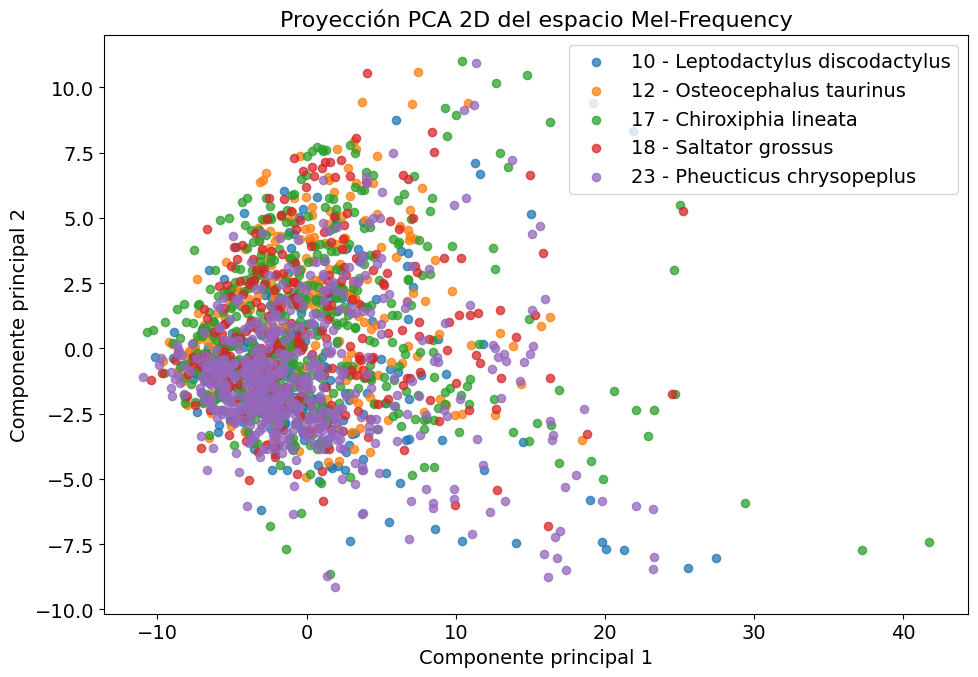

In [20]:
plt.figure(figsize=(10, 7))

for species in sorted(train[target_col].unique()):
    mask = y_train_full.values == species
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        s=35,
        alpha=0.75,
        label=f"{species} - {species_names[species]}"
    )

plt.title("Proyección PCA 2D del espacio Mel-Frequency")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("outputs/figures/pca_2d.png", dpi=300)
plt.show()

## Gráfico UMAP 2D

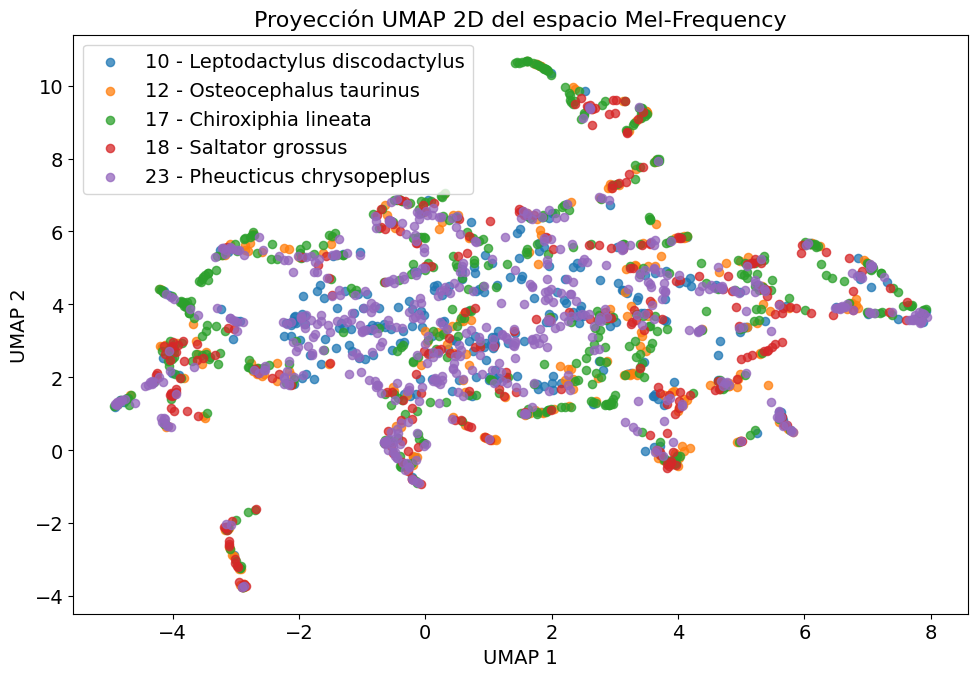

In [21]:
plt.figure(figsize=(10, 7))

for species in sorted(train[target_col].unique()):
    mask = y_train_full.values == species
    plt.scatter(
        X_umap_2d[mask, 0],
        X_umap_2d[mask, 1],
        s=35,
        alpha=0.75,
        label=f"{species} - {species_names[species]}"
    )

plt.title("Proyección UMAP 2D del espacio Mel-Frequency")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig("outputs/figures/umap_2d.png", dpi=300)
plt.show()

## Guardar coordenadas para el integrante 2

In [22]:
pca_umap_coordinates = pd.DataFrame({
    "recording_id": train["recording_id"],
    "species_id": y_train_full.values,
    "species_encoded": y_train_full_encoded,
    "pca_1": X_pca_2d[:, 0],
    "pca_2": X_pca_2d[:, 1],
    "umap_1": X_umap_2d[:, 0],
    "umap_2": X_umap_2d[:, 1]
})

pca_umap_coordinates.to_csv("data/processed/pca_umap_coordinates.csv", index=False)

pca_umap_coordinates.head()

,recording_id,species_id,species_encoded,pca_1,pca_2,umap_1,umap_2
0,8028f97c2,12,1,1.462247,-4.348263,3.330462,5.043878
1,7e60a570a,23,4,-3.366590,-0.560475,0.034782,2.393011
2,b441cf212,23,4,-7.048251,-1.719536,-2.321420,5.316234
3,cddceb09a,12,1,0.100582,-1.574446,1.647949,5.444664
4,adbe22d73,10,0,-6.531605,-1.815511,-2.207414,3.482382


In [24]:
import pandas as pd

class_distribution = pd.read_csv("outputs/tables/class_distribution.csv")
dim_results = pd.read_csv("outputs/tables/dimensionality_reduction_results.csv")

print("=== DISTRIBUCIÓN DE CLASES ===")
print(class_distribution.to_string(index=False))

print("\n=== RESULTADOS DE REDUCCIÓN DIMENSIONAL ===")
print(dim_results.to_string(index=False))

=== DISTRIBUCIÓN DE CLASES ===
 species_id             scientific_name  train_count  test_count  train_percentage  test_percentage
         10 Leptodactylus discodactylus          277          69             14.53            14.47
         12      Osteocephalus taurinus          277          70             14.53            14.68
         17         Chiroxiphia lineata          521         130             27.33            27.25
         18            Saltator grossus          278          69             14.59            14.47
         23     Pheucticus chrysopeplus          553         139             29.01            29.14

=== RESULTADOS DE REDUCCIÓN DIMENSIONAL ===
method  dimensions  execution_time_seconds  explained_variance  trustworthiness
   PCA           2                  0.1599              0.6714           0.8662
   PCA           3                  0.0034              0.7677           0.9403
  UMAP           2                 26.0173                 NaN           0.9777
